# Customer Segmentation for Market Expansion, Honestly Evaluated

A company wants to expand into new markets by sorting prospects into its four existing customer
segments (A/B/C/D). The obvious move is to cluster the customers and call the clusters the
segments. This project does that, and then checks whether it actually works. Two findings up front:

1. **The data's natural clusters do not match the company's four segments.** KMeans clusters agree
   with the labeled segments only slightly better than chance (adjusted Rand index ~0.08), and the
   silhouette score peaks at **three** loosely-separated groups, not four.
2. **The segments are only moderately learnable.** A supervised classifier reaches ~52% accuracy
   against a 28% majority baseline, it clearly beats guessing, but nearly half of prospects would
   still be mis-assigned.

**So the "expand by look-alike targeting into four segments" plan rests on a weak signal.** That is
the useful thing to tell the business, and it is invisible if you stop at a KMeans plot.

The pipeline is a small tested package (`src/customerseg/`) with an object-oriented structure.


In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys; sys.path.insert(0, "../src")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from customerseg import (SegmentationModel, cluster_label_agreement,
                         supervised_ceiling, cluster_profiles)

TEAL="#0e7c86"; TEAL_DEEP="#0a5b63"; SIGNAL="#e23b52"; INK="#12212a"; MUTED="#536068"; NEUTRAL="#aebabf"
plt.rcParams.update({"figure.dpi":110,"axes.spines.top":False,"axes.spines.right":False,
                     "axes.grid":True,"grid.alpha":.25,"font.size":11,"axes.edgecolor":"#d0d9db"})

df_full = pd.read_csv("../data/train.csv").drop(columns=["ID"])
y = df_full.pop("Segmentation"); df = df_full
print(f"{len(df):,} customers, {df.shape[1]} features")
print("segment sizes:", y.value_counts().sort_index().to_dict())

8,068 customers, 9 features
segment sizes: {'A': 1972, 'B': 1858, 'C': 1970, 'D': 2268}


## 1. How many natural groups are there?

Choose the number of clusters by silhouette (higher = better-separated). If the four business
segments were really in the data, we would expect a clear peak at k=4.

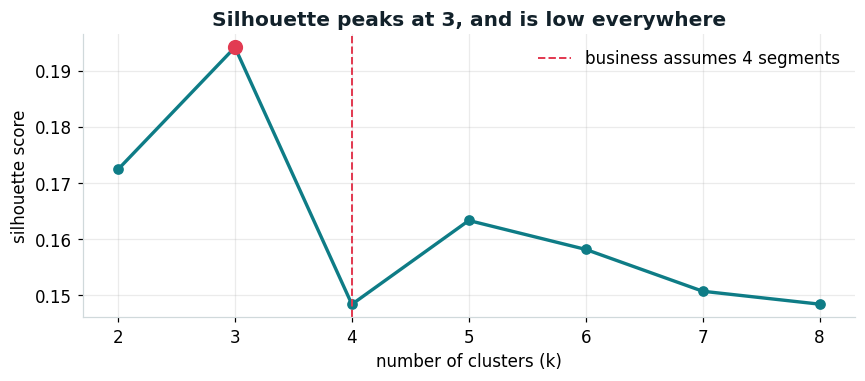

best k by silhouette: 3  (all scores ~0.15-0.19 = weak separation)


In [2]:
model = SegmentationModel(k_range=range(2, 9)).fit(df)
ks = list(model.silhouette_); sil = [model.silhouette_[k] for k in ks]

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(ks, sil, color=TEAL, marker="o", lw=2.2)
ax.axvline(4, color=SIGNAL, ls="--", lw=1.3, label="business assumes 4 segments")
ax.scatter([ks[int(np.argmax(sil))]], [max(sil)], color=SIGNAL, s=80, zorder=5)
ax.set_xlabel("number of clusters (k)"); ax.set_ylabel("silhouette score")
ax.set_title("Silhouette peaks at 3, and is low everywhere", color=INK, fontweight="bold")
ax.legend(frameon=False); plt.tight_layout(); plt.show()
print(f"best k by silhouette: {ks[int(np.argmax(sil))]}  (all scores ~0.15-0.19 = weak separation)")

The scores are low across the board (~0.15-0.19), meaning the customers do not fall into
cleanly-separated groups at all, and the best split is into three, not four.

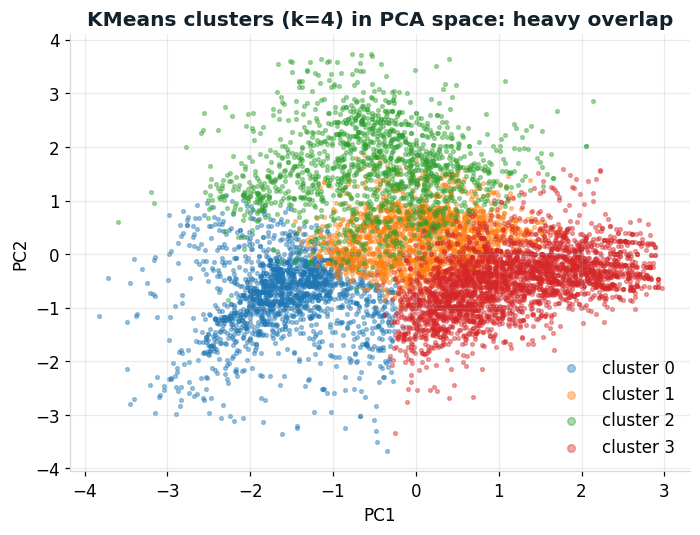

In [3]:
# PCA view of the k=4 solution: overlapping, not four clean islands
m4 = SegmentationModel(k=4).fit(df)
xy = m4.pca_2d()
fig, ax = plt.subplots(figsize=(6.5, 5))
for cl in range(4):
    mask = m4.labels_ == cl
    ax.scatter(xy[mask,0], xy[mask,1], s=6, alpha=0.4, label=f"cluster {cl}")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("KMeans clusters (k=4) in PCA space: heavy overlap", color=INK, fontweight="bold")
ax.legend(frameon=False, markerscale=2); plt.tight_layout(); plt.show()

## 2. What are the clusters, as personas?

Even if they aren't the business's segments, the clusters are interpretable groups.

In [4]:
prof = cluster_profiles(df, m4.labels_)
display(prof[["size","share","Age_mean","Work_Experience_mean","Family_Size_mean",
              "Ever_Married_top","Profession_top","Spending_Score_top"]])

,size,share,Age_mean,Work_Experience_mean,Family_Size_mean,Ever_Married_top,Profession_top,Spending_Score_top
cluster,,,,,,,,
0,1751,0.217,27.4,1.5,4.5,No,Healthcare,Low
1,1872,0.232,38.5,1.0,1.7,No,Artist,Low
2,1498,0.186,37.9,8.5,2.4,Yes,Artist,Low
3,2947,0.365,59.0,1.0,2.8,Yes,Artist,Average


## 3. The real test: do the clusters match the four segments?

This is the question the KMeans-and-plot version never asks. Adjusted Rand index and adjusted
mutual information compare the clusters to the true A/B/C/D labels; near 0 means "no better than
random," near 1 means "a match.\"

adjusted Rand index:        0.083
adjusted mutual information: 0.084


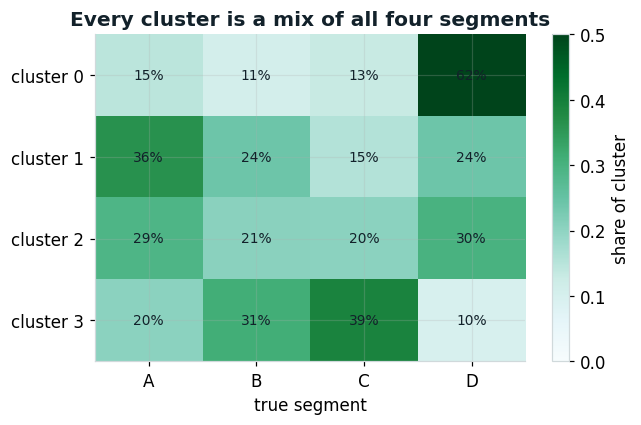

In [5]:
agree = cluster_label_agreement(m4.labels_, y)
print(f"adjusted Rand index:        {agree['adjusted_rand']:.3f}")
print(f"adjusted mutual information: {agree['adjusted_mutual_info']:.3f}")

ct = agree["crosstab"]
ct_norm = ct.div(ct.sum(axis=1), axis=0)   # row-normalized: each cluster's segment mix
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(ct_norm.values, cmap="BuGn", aspect="auto", vmin=0, vmax=0.5)
ax.set_xticks(range(ct.shape[1])); ax.set_xticklabels(ct.columns)
ax.set_yticks(range(ct.shape[0])); ax.set_yticklabels([f"cluster {i}" for i in ct.index])
ax.set_xlabel("true segment"); ax.set_title("Every cluster is a mix of all four segments",
             color=INK, fontweight="bold")
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        ax.text(j, i, f"{ct_norm.values[i,j]:.0%}", ha="center", va="center",
                color=INK, fontsize=9)
fig.colorbar(im, ax=ax, label="share of cluster"); plt.tight_layout(); plt.show()

An ARI of ~0.08 and a cross-tab where every cluster is a blend of all four segments: the
unsupervised structure is **not** the business's segmentation. Renaming clusters "A/B/C/D" would
be fiction.

## 4. Are the segments even predictable? (the supervised ceiling)

If clustering won't recover the segments, can a supervised model, given the labels, at least
predict them for new customers? That is the actual market-expansion task.

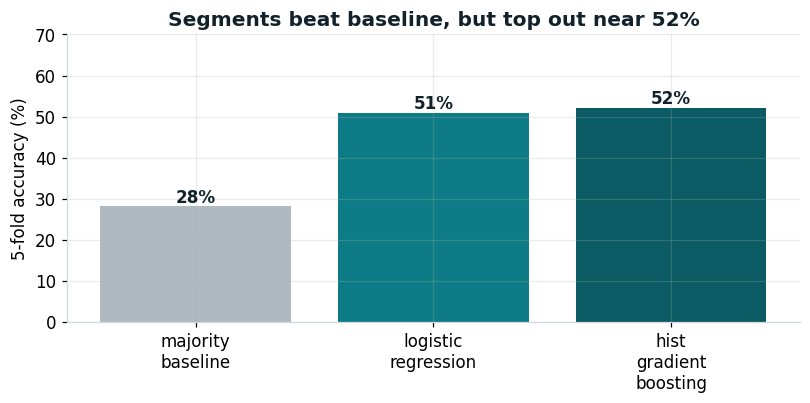

baseline 28%  ->  best model 52%


In [6]:
acc = supervised_ceiling(df, y)
names = ["majority_baseline","logistic_regression","hist_gradient_boosting"]
vals = [acc[n]*100 for n in names]

fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.bar([n.replace("_","\n") for n in names], vals, color=[NEUTRAL, TEAL, TEAL_DEEP])
for i,v in enumerate(vals): ax.text(i, v+1, f"{v:.0f}%", ha="center", fontweight="bold", color=INK)
ax.set_ylabel("5-fold accuracy (%)"); ax.set_ylim(0, 70)
ax.set_title("Segments beat baseline, but top out near 52%", color=INK, fontweight="bold")
plt.tight_layout(); plt.show()
print(f"baseline {acc['majority_baseline']:.0%}  ->  best model {acc['hist_gradient_boosting']:.0%}")

## Verdict and business implication

- **Don't relabel clusters as segments.** The natural structure in the data (three weak, overlapping
  groups) does not correspond to the company's four segments (ARI ~0.08).
- **The segments are real but only moderately learnable.** A classifier nearly doubles the baseline
  (28% -> ~52%), so targeting is possible, but roughly half of new-market prospects would be
  mis-assigned. Plan for that error rate, or invest in richer features.
- **The honest recommendation:** treat market expansion as a supervised classification problem with
  a known ~52% ceiling, not as clustering, and consider whether four segments is even the right
  taxonomy given the data supports about three natural groups.

The value here is not the KMeans plot, it is knowing what the plot does and doesn't support.
Everything is computed by the tested `customerseg` package in `../src/`.
